In [23]:
import pandas as pd
import numpy as np

from sklearn import (pipeline, base, preprocessing, ensemble,feature_selection,
                     model_selection,compose, impute, metrics, linear_model, tree)

import mlflow

In [24]:
df = pd.read_csv('../data/pc_cleaned.csv')

mlflow.set_tracking_uri('http://localhost:5000')
mlflow.set_experiment('Car_price')
mlflow.sklearn.autolog()

In [25]:
df.describe()

,year,mileage,engine_hp,owner_count,vehicle_age,mileage_per_year,price
count,203395.000000,203395.000000,203395.000000,203395.000000,203395.000000,203395.000000,203395.000000
mean,2017.773249,105109.171366,230.289048,3.427125,7.263620,14353.907460,20199.649310
std,3.567002,63175.251148,90.947183,1.539050,3.496587,5985.537224,12491.897342
min,2001.000000,501.000000,90.000000,1.000000,1.000000,45.166667,1500.390000
25%,2015.000000,56605.500000,160.000000,2.000000,5.000000,10338.500000,11015.885000
50%,2018.000000,99479.000000,209.000000,4.000000,7.000000,14431.833333,17748.500000
75%,2020.000000,147951.500000,293.000000,5.000000,10.000000,18396.354167,26725.365000
max,2025.000000,299961.000000,576.000000,5.000000,24.000000,34982.333333,90693.670000


In [26]:
df.columns

Index(['make', 'model', 'year', 'mileage', 'engine_hp', 'transmission',
       'fuel_type', 'drivetrain', 'body_type', 'exterior_color',
       'interior_color', 'owner_count', 'accident_history', 'seller_type',
       'condition', 'trim', 'vehicle_age', 'mileage_per_year', 'price',
       'country'],
      dtype='object')

In [27]:
df = df.drop(columns=['vehicle_age']) # vehicle_age e year dizem a mesma coisa
df = df.drop_duplicates()

In [28]:
target = 'price'
X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test =  model_selection.train_test_split(X,y,
                                                                     test_size=0.3, 
                                                                     random_state=42, 
                                                                     stratify=X['body_type'])
print(f'O dataset contém: {X.shape[0]} linhas.')

O dataset contém: 203395 linhas.


In [29]:
num_pipeline = pipeline.Pipeline([
    ('scaler', preprocessing.StandardScaler()),
])

cat_pipeline = pipeline.Pipeline([
    ('onehot', preprocessing.OneHotEncoder(handle_unknown='ignore')),
])

preprocessor = compose.ColumnTransformer(
    transformers=[
        ('num_transformer', num_pipeline, compose.make_column_selector(dtype_include=np.number)),
        ('target_encoder', preprocessing.TargetEncoder(), ['model']),
        ('cat_transformer', cat_pipeline, compose.make_column_selector(dtype_include=[object])),
    ]
)

selector = feature_selection.SelectKBest(score_func=feature_selection.mutual_info_regression,
                                         k=20)

model = (ensemble.RandomForestRegressor(n_jobs=-1, 
                                        n_estimators=50, 
                                        random_state=42))

pipe = pipeline.Pipeline([
    ('preprocessor',preprocessor),
    ('select_features', selector),
    ('model', model),
])

final_pipe = compose.TransformedTargetRegressor(
    regressor=pipe,
    func=np.log1p,
    inverse_func=np.expm1
)

In [30]:
with mlflow.start_run(run_name=model.__str__()):
    print('fitting...')
    final_pipe.fit(X_train, y_train)
    print('Fit completed!')

    print('Train set')
    y_pred_train = model_selection.cross_val_predict(final_pipe, X_train, y_train, cv=3, n_jobs=-1)
    scores = model_selection.cross_val_score(final_pipe, X_train, y_train, cv=3, scoring='neg_mean_absolute_error', n_jobs=-1)

    rmse_train = metrics.root_mean_squared_error(y_train, y_pred_train)
    mae_train = metrics.mean_absolute_error(y_train, y_pred_train)
    r2_train = metrics.r2_score(y_train, y_pred_train)
    mape_train = metrics.mean_absolute_percentage_error(y_train, y_pred_train)
    mean_scores = -scores.mean()

    print('---')
    print('MAE_train: ', mae_train)
    print('RMSE_train: ', rmse_train)
    print('MAPE_train: ', mape_train)
    print('R2_train: ', r2_train)
    print(f"Média Scores Validação Cruzada: {mean_scores:.4f}")
    print('---')

    print('Test set')
    y_pred = final_pipe.predict(X_test)

    rmse = metrics.root_mean_squared_error(y_test, y_pred)
    mae = metrics.mean_absolute_error(y_test, y_pred)
    r2 = metrics.r2_score(y_test, y_pred)
    mape = metrics.mean_absolute_percentage_error(y_test, y_pred)

    print('MAE_test: ', mae)
    print('RMSE_test: ', rmse)
    print('MAPE_test: ', mape)
    print('R2_test: ', r2)
    print('---')

    mlflow.log_metrics({
    'RMSE' : rmse,
    'MAE' : mae,
    'MAPE' : mape,
    'R2' : r2,

    'RMSE_train' : rmse_train,
    'MAE_train' : mae_train,
    'MAPE_train' : mape_train,
    'R2_train' : r2_train,
    'mean_scores' : mean_scores,
    })

fitting...


2026/04/02 22:10:46 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/henry/Documents/VS/Projetos/car_price/.venv/lib/python3.13/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/04/02 22:15:26 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/henry/Documen

Fit completed!
Train set
---
MAE_train:  1705.9978046782264
RMSE_train:  2501.5418040879117
MAPE_train:  0.09040524270326133
R2_train:  0.9597471908258106
Média Scores Validação Cruzada: 1704.5853
---
Test set


2026/04/02 22:34:28 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/henry/Documents/VS/Projetos/car_price/.venv/lib/python3.13/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


MAE_test:  1698.1685069181813
RMSE_test:  2493.872692461359
MAPE_test:  0.08936244544903389
R2_test:  0.960490229351635
---
🏃 View run RandomForestRegressor(n_estimators=50, n_jobs=-1, random_state=42) at: http://localhost:5000/#/experiments/1/runs/9f15f7d1fb3b4674861bc05706a0e8a7
🧪 View experiment at: http://localhost:5000/#/experiments/1


In [ ]:
selector = final_pipe.regressor_.named_steps['select_features']
preprocessor = final_pipe.regressor_.named_steps['preprocessor']

feature_names = preprocessor.get_feature_names_out()
features_scores = selector.scores_
best_features = pd.Series(index=feature_names, data= features_scores)
best_features = best_features.sort_values(ascending=False)

<Axes: >

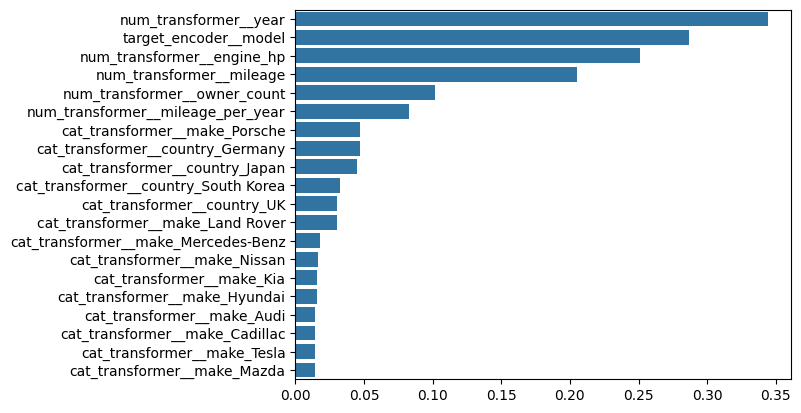

In [33]:
import seaborn as sns
sns.barplot(data=best_features.head(20), orient='y')

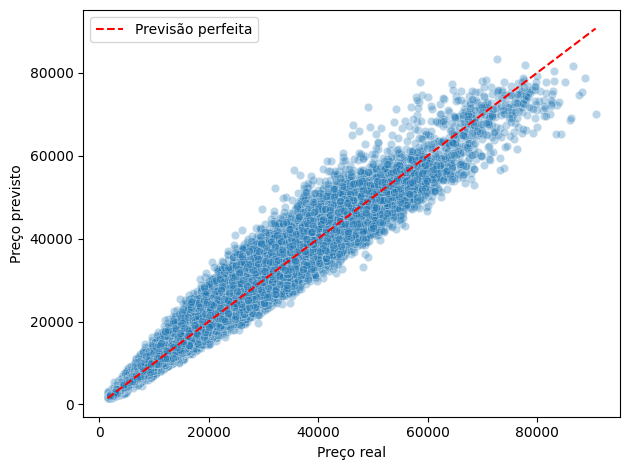

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.scatterplot(x=y_test, y=y_pred, alpha=0.3,)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', linewidth=1.5, label='Previsão perfeita')
plt.xlabel('Preço real')
plt.ylabel('Preço previsto')
plt.legend()
plt.tight_layout()
plt.show()